In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from dateutil.relativedelta import relativedelta
from sklearn.preprocessing import MinMaxScaler



In [2]:
df= pd.read_csv('../data/DataWave_Music_cleaned.csv')

In [3]:
df.head()

,user_id,country,age,gender,subscription_type,avg_listening_hours_per_week,total_songs_played,skip_rate,satisfaction_score,churned,monthly_fee,join_date
0,U1403,nepal,23,Female,Premium,11.5,510,0.05,2.0,0,7.99,21/03/2024
1,U1165,nepal,63,Male,Student,11.3,526,0.05,3.0,0,0.00,08/10/2023
2,U1474,usa,45,Female,Premium,2.0,476,0.30,3.0,0,7.99,04/05/2022
3,U1478,nigeria,16,Female,Family,12.1,529,0.20,5.0,1,12.99,16/12/2023
4,U1609,ghana,29,Male,Free,6.4,477,0.20,3.0,0,7.99,28/03/2022


In [4]:
df.loc[df['subscription_type'] == 'Student', ["user_id","country",'age','gender','subscription_type','avg_listening_hours_per_week','total_songs_played',	"skip_rate","satisfaction_score",	"churned","monthly_fee",'join_date']] 

,user_id,country,age,gender,subscription_type,avg_listening_hours_per_week,total_songs_played,skip_rate,satisfaction_score,churned,monthly_fee,join_date
1,U1165,nepal,63,Male,Student,11.3,526,0.05,3.0,0,0.00,08/10/2023
5,U1691,united kingdom,16,Female,Student,11.0,548,0.30,3.0,0,9.99,25/04/2022
8,U1514,india,23,Female,Student,21.5,514,0.15,3.0,0,9.99,12/02/2022
11,U1158,kenya,64,Male,Student,7.6,440,0.10,5.0,0,7.99,09/05/2022
13,U1120,ghana,46,Male,Student,11.2,509,0.20,5.0,1,9.99,15/02/2023
...,...,...,...,...,...,...,...,...,...,...,...,...
666,U1269,united kingdom,37,Female,Student,12.0,456,0.05,2.0,0,9.99,05/11/2022
671,U1329,united kingdom,48,Male,Student,9.7,530,0.10,1.0,0,7.99,15/05/2023
684,U1415,ghana,53,Male,Student,5.8,506,0.30,3.0,1,12.99,23/11/2022
686,U1680,kenya,59,Female,Student,23.6,495,0.05,2.0,1,5.00,31/07/2023


In [5]:
total_per_country = df.groupby('country').size()

In [6]:
county_churn = df[df['churned'] == 1].groupby('country').size()
churn_percentage = (county_churn /total_per_country ) *100
print('Churn percentage for each country(%) :')
print(churn_percentage.round(2))

Churn percentage for each country(%) :
country
brazil            38.46
ghana             36.21
india             23.89
kenya             32.31
nepal             26.09
nigeria           36.92
south africa      27.78
united kingdom    32.60
usa               22.97
dtype: float64


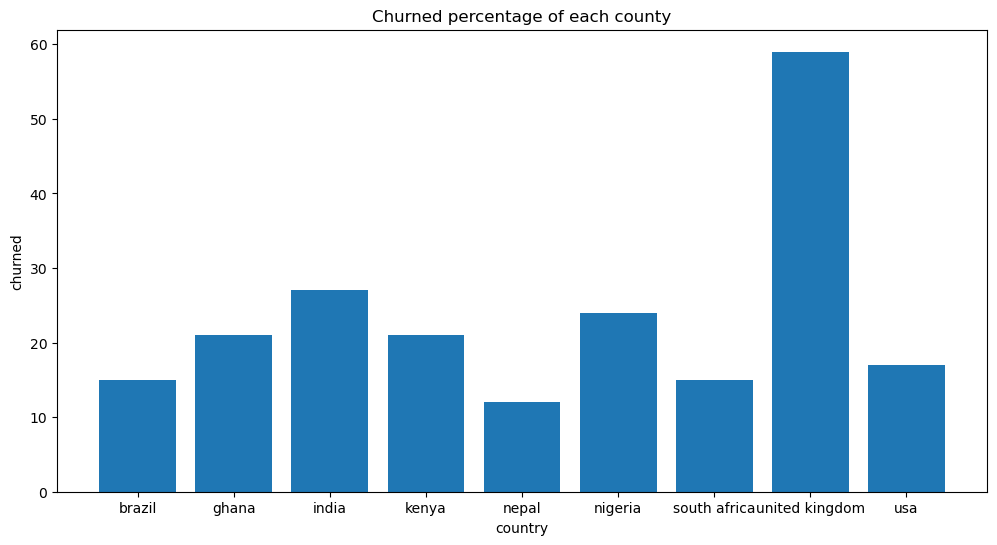

In [7]:
plt.figure(figsize=(12, 6))
plt.bar(county_churn.index, county_churn.values)
plt.title("Churned percentage of each county")
plt.xlabel('country')
plt.ylabel('churned')
plt.show()

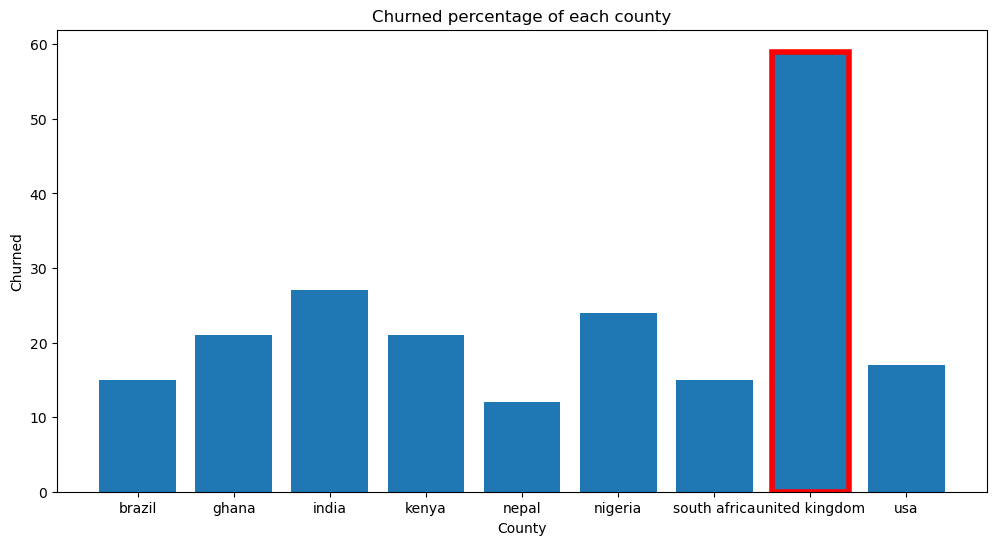

In [83]:
plt.figure(figsize=(12, 6))

bars = plt.bar(county_churn.index, county_churn.values)

# Find the index of the highest churn
max_index = county_churn.values.argmax()

# Highlight the highest bar with a red border
bars[max_index].set_edgecolor('red')
bars[max_index].set_linewidth(4)

plt.title("Churned percentage of each county")
plt.xlabel('County')
plt.ylabel('Churned')
plt.show()


In [8]:
uk_data = df[df['country']=='united kingdom']
uk_data 

,user_id,country,age,gender,subscription_type,avg_listening_hours_per_week,total_songs_played,skip_rate,satisfaction_score,churned,monthly_fee,join_date
5,U1691,united kingdom,16,Female,Student,11.0,548,0.30,3.0,0,9.99,25/04/2022
7,U1490,united kingdom,57,Female,Premium,11.3,476,0.30,3.0,0,7.99,01/12/2022
12,U1387,united kingdom,49,Female,Free,11.2,508,0.10,5.0,1,9.99,05/02/2022
17,U1508,united kingdom,48,Female,Family,8.7,511,0.30,4.0,1,0.00,18/09/2022
22,U1424,united kingdom,26,Female,Student,9.5,498,0.10,3.0,0,9.99,11/10/2022
...,...,...,...,...,...,...,...,...,...,...,...,...
672,U1104,united kingdom,22,Female,Premium,2.0,497,0.25,5.0,0,9.99,12/07/2023
676,U1679,united kingdom,40,Other,Free,2.1,462,0.25,1.0,0,9.99,06/06/2022
678,U1229,united kingdom,34,Male,Free,19.4,508,0.25,1.0,0,7.99,04/08/2022
687,U1418,united kingdom,42,Male,Family,6.7,507,0.25,5.0,0,0.00,02/07/2024


In [9]:
uk_data.shape

(181, 12)

In [10]:
uk_age=uk_data['age'].unique()
uk_age.sort()
uk_age 

array([13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29,
       30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46,
       47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63,
       64])

In [11]:
uk_data['age_groups']= pd.cut(uk_data['age'], bins=[0,18,25,35,45,55,65], labels=['<18','18-24','25-34','35-44','45-54','55-64'])
print('Age groups in UK data: \n', uk_data)

Age groups in UK data: 
     user_id         country  age  gender subscription_type  \
5     U1691  united kingdom   16  Female           Student   
7     U1490  united kingdom   57  Female           Premium   
12    U1387  united kingdom   49  Female              Free   
17    U1508  united kingdom   48  Female            Family   
22    U1424  united kingdom   26  Female           Student   
..      ...             ...  ...     ...               ...   
672   U1104  united kingdom   22  Female           Premium   
676   U1679  united kingdom   40   Other              Free   
678   U1229  united kingdom   34    Male              Free   
687   U1418  united kingdom   42    Male            Family   
690   U1584  united kingdom   30    Male           Student   

     avg_listening_hours_per_week  total_songs_played  skip_rate  \
5                            11.0                 548       0.30   
7                            11.3                 476       0.30   
12                        

C:\Users\Miraj Gansi\AppData\Local\Temp\ipykernel_14308\1820513922.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  uk_data['age_groups']= pd.cut(uk_data['age'], bins=[0,18,25,35,45,55,65], labels=['<18','18-24','25-34','35-44','45-54','55-64'])


In [12]:
uk_age_churn = uk_data.groupby(['age_groups'])['churned'].value_counts(normalize=True).unstack() * 100
uk_age_churn

C:\Users\Miraj Gansi\AppData\Local\Temp\ipykernel_14308\2106467467.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  uk_age_churn = uk_data.groupby(['age_groups'])['churned'].value_counts(normalize=True).unstack() * 100


churned,0,1
age_groups,,
<18,65.517241,34.482759
18-24,69.565217,30.434783
25-34,62.857143,37.142857
35-44,80.000000,20.000000
45-54,71.428571,28.571429
55-64,58.333333,41.666667


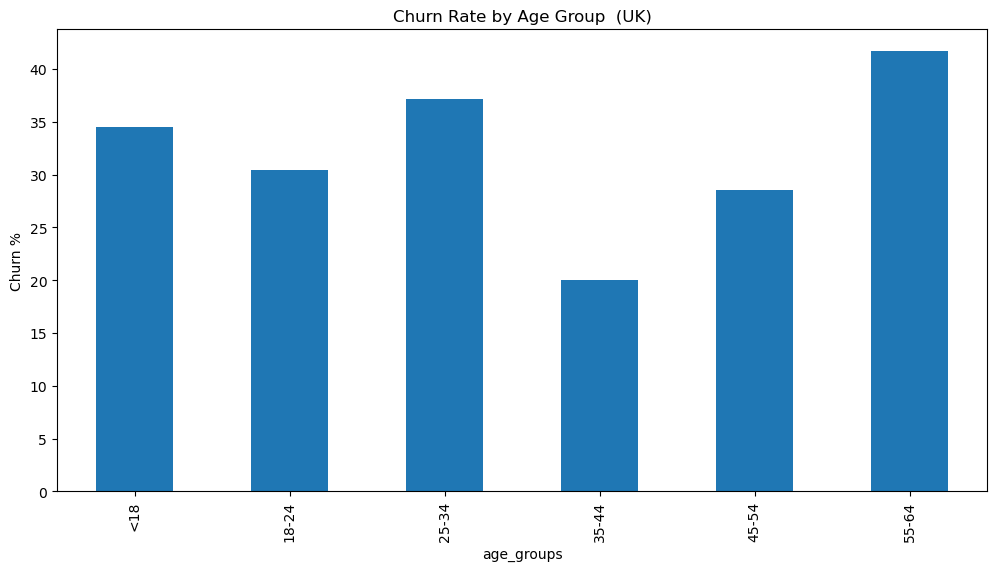

In [13]:
uk_age_churn_yes = uk_age_churn[1] 

uk_age_churn_yes.plot(kind='bar', figsize=(12,6))
plt.ylabel('Churn %')
plt.title('Churn Rate by Age Group  (UK)')
plt.show()

In [14]:
gender_counts = uk_data['gender'].value_counts()
print(gender_counts)

gender
Male      91
Female    64
Other     26
Name: count, dtype: int64


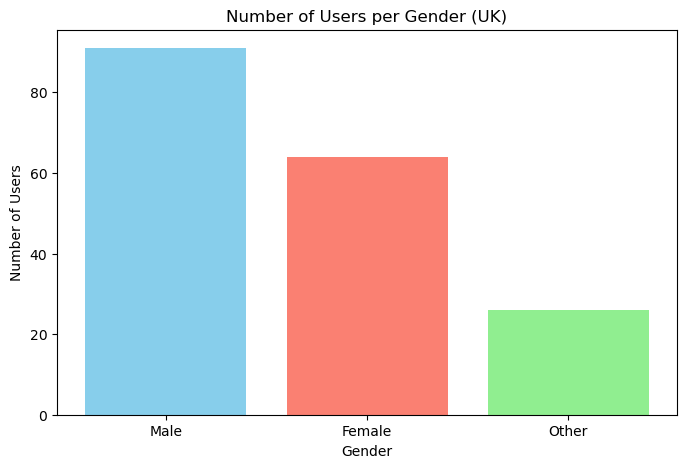

In [15]:
plt.figure(figsize=(8,5))
plt.bar(gender_counts.index, gender_counts.values, color=['skyblue', 'salmon', 'lightgreen'])
plt.xlabel('Gender')
plt.ylabel('Number of Users')
plt.title('Number of Users per Gender (UK)')
plt.show()

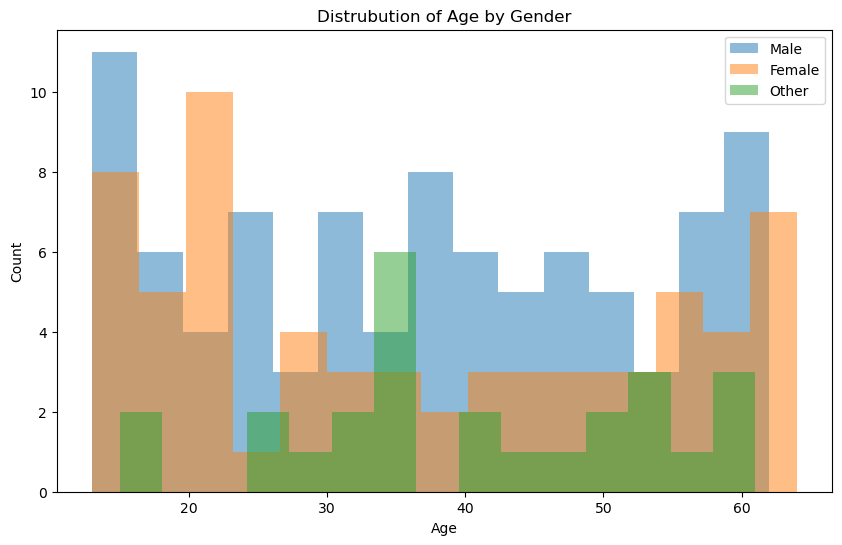

In [16]:
plt.figure(figsize=(10, 6))
for gender in ['Male', 'Female', 'Other']:
    subset = uk_data[uk_data['gender'] == gender]
    plt.hist(subset['age'], bins=15, alpha=0.5, label=gender)

plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Distrubution of Age by Gender')
plt.legend()
plt.show()

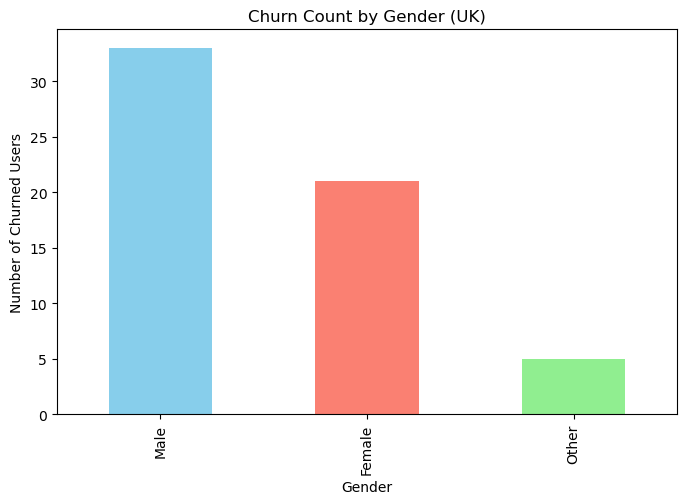

In [17]:
churned_users = uk_data[uk_data['churned'] == 1]

gender_churn_counts = churned_users['gender'].value_counts()

# Plot
plt.figure(figsize=(8,5))
gender_churn_counts.plot(kind='bar', color=['skyblue', 'salmon', 'lightgreen'])
plt.xlabel('Gender')
plt.ylabel('Number of Churned Users')
plt.title('Churn Count by Gender (UK)')
plt.show()

In [18]:
uk_data.head()

,user_id,country,age,gender,subscription_type,avg_listening_hours_per_week,total_songs_played,skip_rate,satisfaction_score,churned,monthly_fee,join_date,age_groups
5,U1691,united kingdom,16,Female,Student,11.0,548,0.3,3.0,0,9.99,25/04/2022,<18
7,U1490,united kingdom,57,Female,Premium,11.3,476,0.3,3.0,0,7.99,01/12/2022,55-64
12,U1387,united kingdom,49,Female,Free,11.2,508,0.1,5.0,1,9.99,05/02/2022,45-54
17,U1508,united kingdom,48,Female,Family,8.7,511,0.3,4.0,1,0.00,18/09/2022,45-54
22,U1424,united kingdom,26,Female,Student,9.5,498,0.1,3.0,0,9.99,11/10/2022,25-34


In [19]:
uk_gender_age_churn =(uk_data.groupby(['age_groups','gender'])['churned'].value_counts(normalize= True).unstack()[1]*100)
print("percentage of gender and age churn in United kingdom")
print(uk_gender_age_churn)

percentage of gender and age churn in United kingdom
age_groups  gender
<18         Female    36.363636
            Male      37.500000
            Other      0.000000
18-24       Female    33.333333
            Male      30.000000
            Other      0.000000
25-34       Female    40.000000
            Male      50.000000
            Other     11.111111
35-44       Female    14.285714
            Male      26.315789
            Other      0.000000
45-54       Female    37.500000
            Male      21.428571
            Other     33.333333
55-64       Female    31.250000
            Male      50.000000
            Other     50.000000
Name: 1, dtype: float64


C:\Users\Miraj Gansi\AppData\Local\Temp\ipykernel_14308\3822810160.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  uk_gender_age_churn =(uk_data.groupby(['age_groups','gender'])['churned'].value_counts(normalize= True).unstack()[1]*100)


<Figure size 1200x600 with 0 Axes>

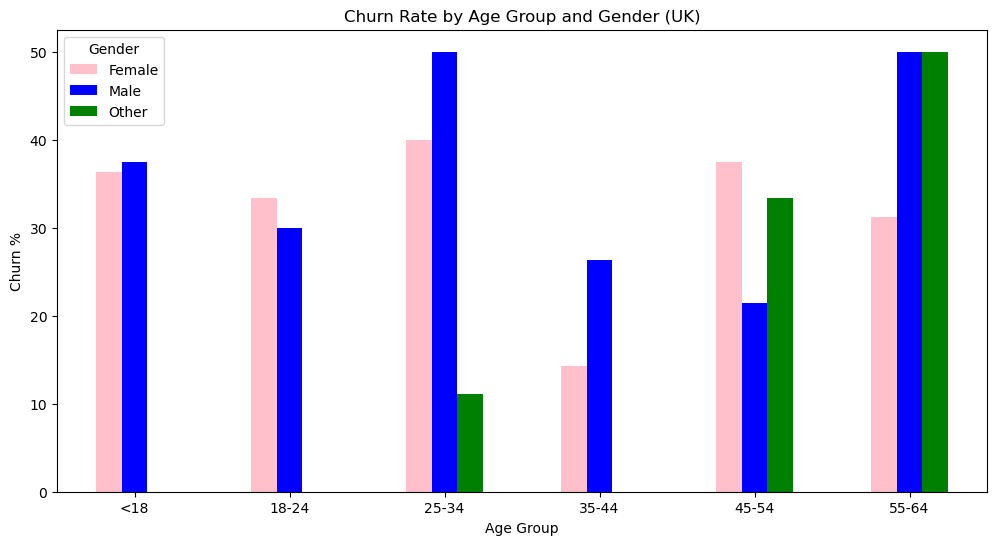

In [20]:
plt.figure(figsize=(12,6))
uk_gender_age_churn.unstack().plot(
    kind='bar',
    figsize=(12,6),
    color=['pink', 'blue', 'green']  # colors for M, F, O
)

plt.ylabel('Churn %')
plt.xlabel('Age Group')
plt.title('Churn Rate by Age Group and Gender (UK)')
plt.legend(title='Gender')
plt.xticks(rotation=0)
plt.show()

In [21]:
subbscription_fee =uk_data['monthly_fee'].unique()
print("Monthly fee paid bby userd in Uk")
print(subbscription_fee)

Monthly fee paid bby userd in Uk
[ 9.99  7.99  0.   12.99  5.  ]


In [22]:
uk_data['join_date']= pd.to_datetime(uk_data['join_date'])
uk_data['join_year'] = uk_data['join_date'].dt.year
uk_data

C:\Users\Miraj Gansi\AppData\Local\Temp\ipykernel_14308\1765371121.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  uk_data['join_date']= pd.to_datetime(uk_data['join_date'])
C:\Users\Miraj Gansi\AppData\Local\Temp\ipykernel_14308\1765371121.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  uk_data['join_date']= pd.to_datetime(uk_data['join_date'])
C:\Users\Miraj Gansi\AppData\Local\Temp\ipykernel_14308\1765371121.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.o

,user_id,country,age,gender,subscription_type,avg_listening_hours_per_week,total_songs_played,skip_rate,satisfaction_score,churned,monthly_fee,join_date,age_groups,join_year
5,U1691,united kingdom,16,Female,Student,11.0,548,0.30,3.0,0,9.99,2022-04-25,<18,2022
7,U1490,united kingdom,57,Female,Premium,11.3,476,0.30,3.0,0,7.99,2022-12-01,55-64,2022
12,U1387,united kingdom,49,Female,Free,11.2,508,0.10,5.0,1,9.99,2022-02-05,45-54,2022
17,U1508,united kingdom,48,Female,Family,8.7,511,0.30,4.0,1,0.00,2022-09-18,45-54,2022
22,U1424,united kingdom,26,Female,Student,9.5,498,0.10,3.0,0,9.99,2022-10-11,25-34,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
672,U1104,united kingdom,22,Female,Premium,2.0,497,0.25,5.0,0,9.99,2023-07-12,18-24,2023
676,U1679,united kingdom,40,Other,Free,2.1,462,0.25,1.0,0,9.99,2022-06-06,35-44,2022
678,U1229,united kingdom,34,Male,Free,19.4,508,0.25,1.0,0,7.99,2022-08-04,25-34,2022
687,U1418,united kingdom,42,Male,Family,6.7,507,0.25,5.0,0,0.00,2024-07-02,35-44,2024


In [23]:
def calculate_months(start_date, end_date):
    rd= relativedelta(end_date, start_date)
    return rd.years * 12 + rd.months

In [24]:
today = pd.Timestamp.today()
uk_data['months_active'] = uk_data['join_date'].apply(lambda x:calculate_months(x, today))
uk_data # adding months active to understand if the lognterm user are leaving or short term

C:\Users\Miraj Gansi\AppData\Local\Temp\ipykernel_14308\1905405561.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  uk_data['months_active'] = uk_data['join_date'].apply(lambda x:calculate_months(x, today))


,user_id,country,age,gender,subscription_type,avg_listening_hours_per_week,total_songs_played,skip_rate,satisfaction_score,churned,monthly_fee,join_date,age_groups,join_year,months_active
5,U1691,united kingdom,16,Female,Student,11.0,548,0.30,3.0,0,9.99,2022-04-25,<18,2022,43
7,U1490,united kingdom,57,Female,Premium,11.3,476,0.30,3.0,0,7.99,2022-12-01,55-64,2022,35
12,U1387,united kingdom,49,Female,Free,11.2,508,0.10,5.0,1,9.99,2022-02-05,45-54,2022,45
17,U1508,united kingdom,48,Female,Family,8.7,511,0.30,4.0,1,0.00,2022-09-18,45-54,2022,38
22,U1424,united kingdom,26,Female,Student,9.5,498,0.10,3.0,0,9.99,2022-10-11,25-34,2022,37
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
672,U1104,united kingdom,22,Female,Premium,2.0,497,0.25,5.0,0,9.99,2023-07-12,18-24,2023,28
676,U1679,united kingdom,40,Other,Free,2.1,462,0.25,1.0,0,9.99,2022-06-06,35-44,2022,41
678,U1229,united kingdom,34,Male,Free,19.4,508,0.25,1.0,0,7.99,2022-08-04,25-34,2022,39
687,U1418,united kingdom,42,Male,Family,6.7,507,0.25,5.0,0,0.00,2024-07-02,35-44,2024,16


In [25]:
np.unique(uk_data['months_active'])


array([11, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28,
       29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45,
       46])

In [26]:
uk_data['tenure_group'] = pd.cut(
    uk_data['months_active'],
    bins=[10, 15, 20, 25, 30, 35, 40, 45],
    labels=['11–15 Mo', '16–20 Mo', '21–25 Mo', '26–30 Mo', '31–35 Mo', '36–40 Mo',  '41–45 Mo']
)

C:\Users\Miraj Gansi\AppData\Local\Temp\ipykernel_14308\757891206.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  uk_data['tenure_group'] = pd.cut(


In [27]:
month_churn_pivot = uk_data.pivot_table(
    values= 'churned',
    index='tenure_group', aggfunc='mean'
)*100

C:\Users\Miraj Gansi\AppData\Local\Temp\ipykernel_14308\1819352982.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  month_churn_pivot = uk_data.pivot_table(


In [28]:
monthly_churn= uk_data.groupby('months_active')['churned'].mean()*100

In [29]:
highest_churn_month = monthly_churn.idxmax()
highest_churn_rate = monthly_churn.max()
print(f"Highest churn occurs at month {highest_churn_month} with churn rate {highest_churn_rate:.2f}%")

lowest_churn_month = monthly_churn.idxmin()
lowest_churn_rate = monthly_churn.idxmin()
print(f"Highest churn occurs at month {lowest_churn_month} with churn rate {lowest_churn_rate:.2f}%")

Highest churn occurs at month 45 with churn rate 100.00%
Highest churn occurs at month 11 with churn rate 11.00%


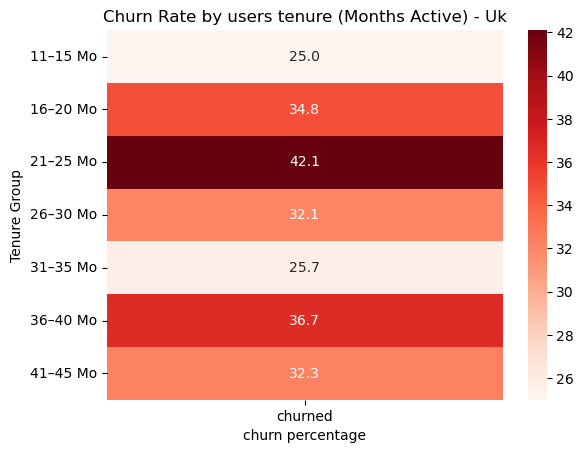

In [30]:
plt.Figure(figsize=(12,6))
sns.heatmap(month_churn_pivot, annot= True, fmt='.1f', cmap = 'Reds')
plt.title   ('Churn Rate by users tenure (Months Active) - Uk')
plt.ylabel("Tenure Group")
plt.xlabel('churn percentage')
plt.show()

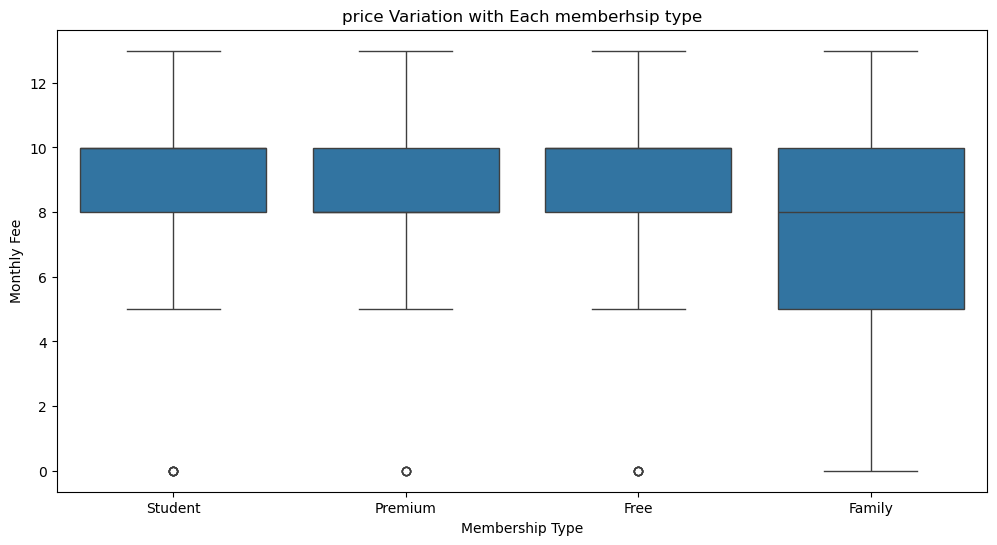

In [31]:
plt.figure(figsize=(12,6))
sns.boxplot(x= 'subscription_type', y='monthly_fee', data = uk_data)
plt.title('price Variation with Each memberhsip type')
plt.ylabel('Monthly Fee')
plt.xlabel('Membership Type')
plt.show()

In [32]:
price_churn_membership = uk_data.groupby(['subscription_type', 'monthly_fee'])['churned'].mean()*100
price_churn_membership = price_churn_membership.reset_index()
price_churn_membership.rename(columns={'churned':'churn_rate'}, inplace= True)

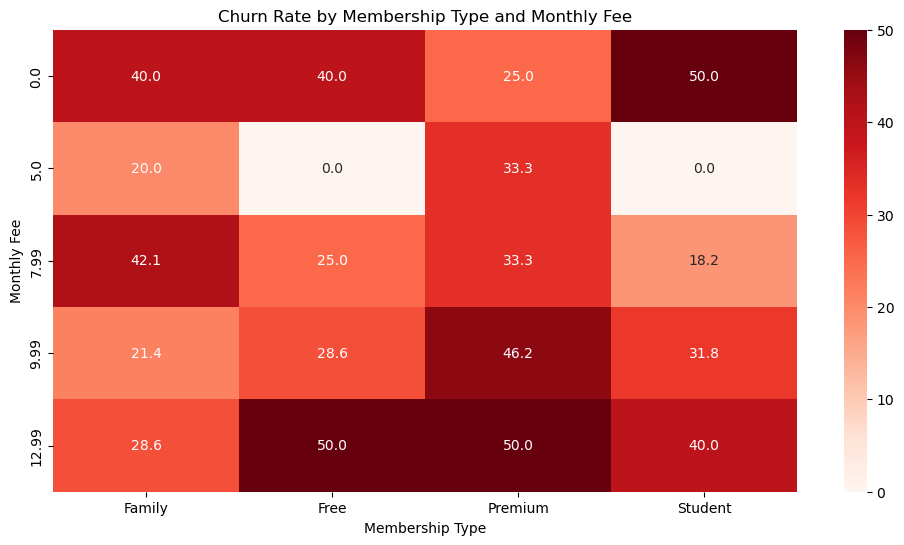

In [33]:
pivot = price_churn_membership.pivot(index='monthly_fee', columns='subscription_type', values='churn_rate')

plt.figure(figsize=(12,6))
sns.heatmap(pivot, annot=True, fmt=".1f", cmap='Reds')
plt.title('Churn Rate by Membership Type and Monthly Fee')
plt.ylabel('Monthly Fee')
plt.xlabel('Membership Type')
plt.show()

In [34]:
uk_data.groupby(['subscription_type','monthly_fee']).size()

subscription_type  monthly_fee
Family             0.00           10
                   5.00            5
                   7.99           19
                   9.99           14
                   12.99           7
Free               0.00            5
                   5.00            2
                   7.99            8
                   9.99           14
                   12.99           2
Premium            0.00            4
                   5.00            3
                   7.99           15
                   9.99           13
                   12.99           6
Student            0.00            6
                   5.00            5
                   7.99           11
                   9.99           22
                   12.99          10
dtype: int64

In [35]:
uk_data.groupby(['subscription_type','monthly_fee'])['join_date'].min()

subscription_type  monthly_fee
Family             0.00          2022-04-14
                   5.00          2022-05-11
                   7.99          2022-01-23
                   9.99          2022-06-16
                   12.99         2022-02-05
Free               0.00          2022-05-26
                   5.00          2023-02-23
                   7.99          2022-07-05
                   9.99          2022-02-05
                   12.99         2024-08-30
Premium            0.00          2022-03-09
                   5.00          2022-04-02
                   7.99          2022-03-03
                   9.99          2022-06-29
                   12.99         2022-05-06
Student            0.00          2023-05-27
                   5.00          2022-05-13
                   7.99          2022-03-23
                   9.99          2022-01-18
                   12.99         2022-01-17
Name: join_date, dtype: datetime64[ns]

In [36]:
uk_data.head()

,user_id,country,age,gender,subscription_type,avg_listening_hours_per_week,total_songs_played,skip_rate,satisfaction_score,churned,monthly_fee,join_date,age_groups,join_year,months_active,tenure_group
5,U1691,united kingdom,16,Female,Student,11.0,548,0.3,3.0,0,9.99,2022-04-25,<18,2022,43,41–45 Mo
7,U1490,united kingdom,57,Female,Premium,11.3,476,0.3,3.0,0,7.99,2022-12-01,55-64,2022,35,31–35 Mo
12,U1387,united kingdom,49,Female,Free,11.2,508,0.1,5.0,1,9.99,2022-02-05,45-54,2022,45,41–45 Mo
17,U1508,united kingdom,48,Female,Family,8.7,511,0.3,4.0,1,0.00,2022-09-18,45-54,2022,38,36–40 Mo
22,U1424,united kingdom,26,Female,Student,9.5,498,0.1,3.0,0,9.99,2022-10-11,25-34,2022,37,36–40 Mo


In [37]:
most_joined = uk_data.groupby(['join_year']).size()
most_joined

join_year
2022    76
2023    65
2024    40
dtype: int64

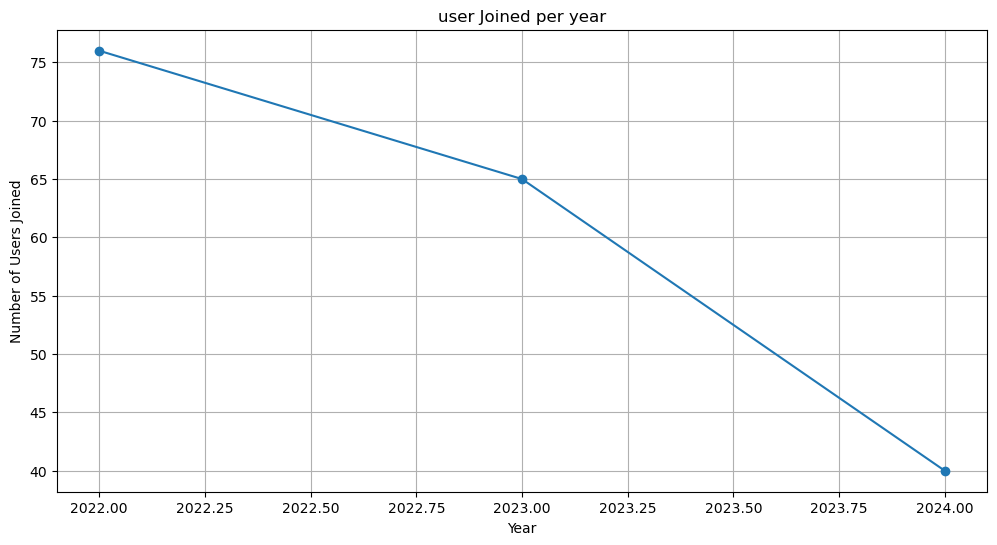

In [38]:

plt.figure(figsize=(12,6))
plt.plot(most_joined.index, most_joined.values, marker='o')
plt.xlabel('Year')
plt.ylabel('Number of Users Joined')
plt.title("user Joined per year")
plt.grid(True)
plt.show()

In [39]:
most_joined_user_and_fee = uk_data.groupby(['join_year','monthly_fee']).size()
most_joined_user_and_fee 

join_year  monthly_fee
2022       0.00           11
           5.00            9
           7.99           23
           9.99           22
           12.99          11
2023       0.00           11
           5.00            4
           7.99           19
           9.99           26
           12.99           5
2024       0.00            3
           5.00            2
           7.99           11
           9.99           15
           12.99           9
dtype: int64

In [40]:
joined_users_fee_pivot = most_joined_user_and_fee.unstack(fill_value=0)

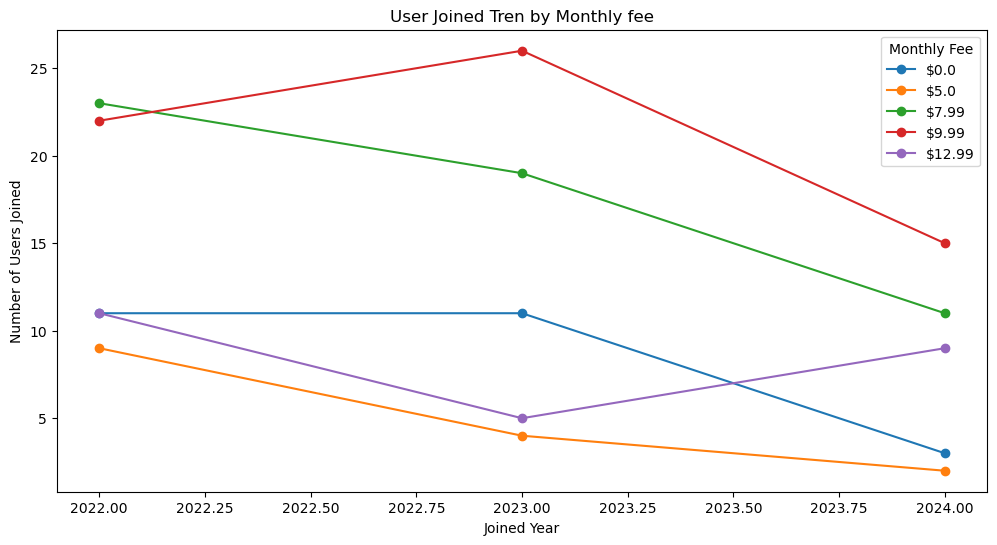

In [41]:
plt.figure(figsize=(12,6))
for monthly_fee in joined_users_fee_pivot:
    plt.plot(joined_users_fee_pivot.index, joined_users_fee_pivot[monthly_fee], marker ='o', label = f"${monthly_fee}")
plt.title("User Joined Tren by Monthly fee")
plt.xlabel("Joined Year")
plt.ylabel("Number of Users Joined")
plt.legend(title= "Monthly Fee")
plt.grid(False)
plt.show()

In [42]:
gender_fee_churn =( uk_data[uk_data['churned']==1].groupby(['monthly_fee', 'gender']).size())

In [43]:
gender_fee_pivot = gender_fee_churn.unstack(fill_value= 0)
gender_fee_pivot

gender,Female,Male,Other
monthly_fee,,,
0.00,4,4,2
5.00,2,0,0
7.99,3,13,1
9.99,9,10,1
12.99,3,6,1


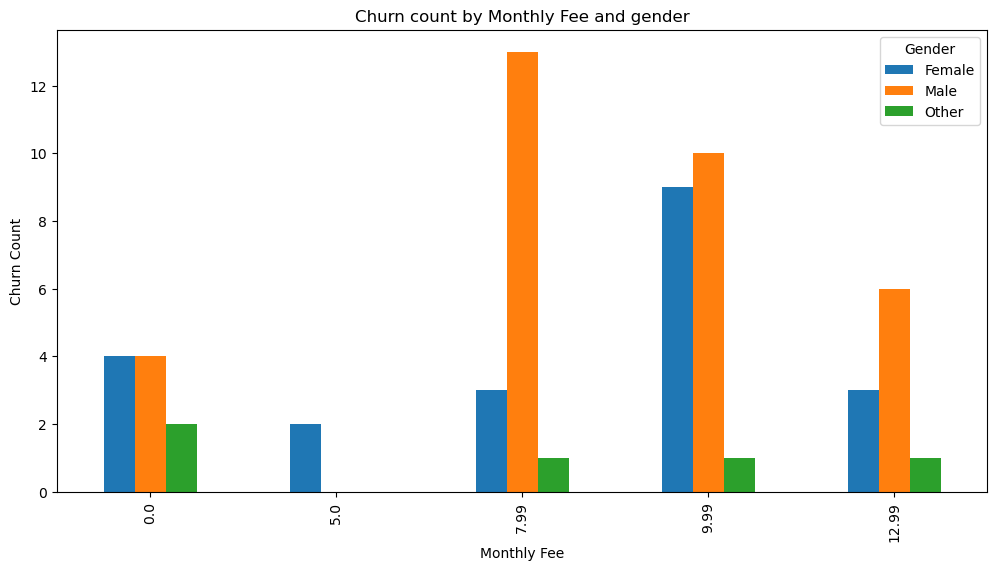

In [44]:
gender_fee_pivot.plot(kind='bar', figsize=(12,6))
plt.title("Churn count by Monthly Fee and gender")
plt.xlabel("Monthly Fee")
plt.ylabel('Churn Count')
plt.legend(title='Gender')
plt.show()

In [45]:
uk_data.head()

,user_id,country,age,gender,subscription_type,avg_listening_hours_per_week,total_songs_played,skip_rate,satisfaction_score,churned,monthly_fee,join_date,age_groups,join_year,months_active,tenure_group
5,U1691,united kingdom,16,Female,Student,11.0,548,0.3,3.0,0,9.99,2022-04-25,<18,2022,43,41–45 Mo
7,U1490,united kingdom,57,Female,Premium,11.3,476,0.3,3.0,0,7.99,2022-12-01,55-64,2022,35,31–35 Mo
12,U1387,united kingdom,49,Female,Free,11.2,508,0.1,5.0,1,9.99,2022-02-05,45-54,2022,45,41–45 Mo
17,U1508,united kingdom,48,Female,Family,8.7,511,0.3,4.0,1,0.00,2022-09-18,45-54,2022,38,36–40 Mo
22,U1424,united kingdom,26,Female,Student,9.5,498,0.1,3.0,0,9.99,2022-10-11,25-34,2022,37,36–40 Mo


In [46]:
avg_listening = uk_data.groupby('churned')['avg_listening_hours_per_week'].mean()
print('AAverage listening Hours: Churned vs Non-Churned (Uk)')
print(avg_listening)

AAverage listening Hours: Churned vs Non-Churned (Uk)
churned
0    10.562295
1    10.059322
Name: avg_listening_hours_per_week, dtype: float64


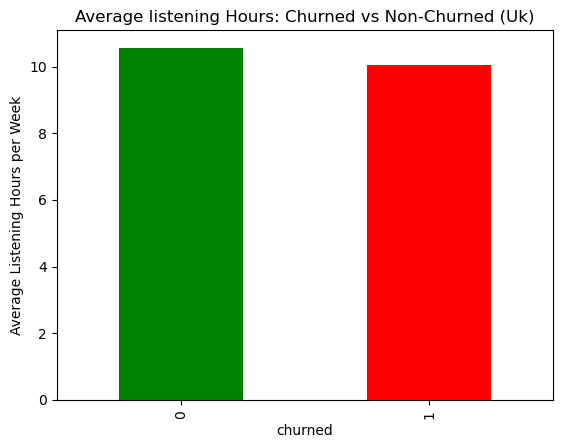

In [47]:
plt.Figure(figsize=(12,6))
avg_listening.plot(kind ='bar', color= ['green', 'red'])
plt.ylabel('Average Listening Hours per Week')
plt.xlabel("churned")
plt.title("Average listening Hours: Churned vs Non-Churned (Uk)")
plt.show()

In [48]:
avg_songs = uk_data.groupby('churned')['total_songs_played'].mean()
print('Total Songs played: Churned vs Non-Churned (Uk)')
print(avg_songs)

Total Songs played: Churned vs Non-Churned (Uk)
churned
0    498.549180
1    498.762712
Name: total_songs_played, dtype: float64


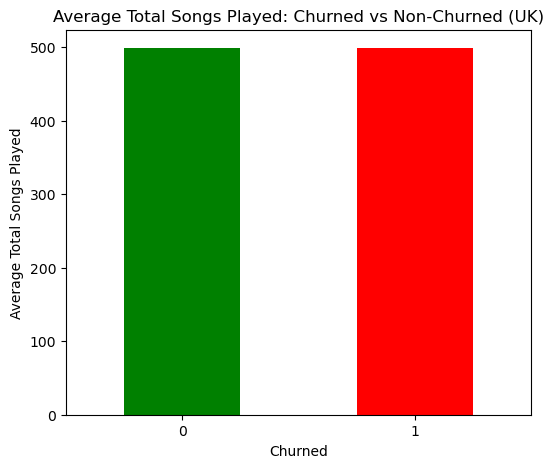

In [49]:
plt.figure(figsize=(6,5))
avg_songs.plot(kind='bar', color=['green','red'])
plt.ylabel('Average Total Songs Played')
plt.xlabel('Churned')
plt.title('Average Total Songs Played: Churned vs Non-Churned (UK)')
plt.xticks(rotation=0)
plt.show()

In [85]:
total_songs_by_gender = uk_data.groupby('age_groups')['total_songs_played'].sum()
print(total_songs_by_gender)


age_groups
<18      14557
18-24    11456
25-34    17406
35-44    14875
45-54    14105
55-64    17851
Name: total_songs_played, dtype: int64


C:\Users\Miraj Gansi\AppData\Local\Temp\ipykernel_14308\2012170680.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  total_songs_by_gender = uk_data.groupby('age_groups')['total_songs_played'].sum()


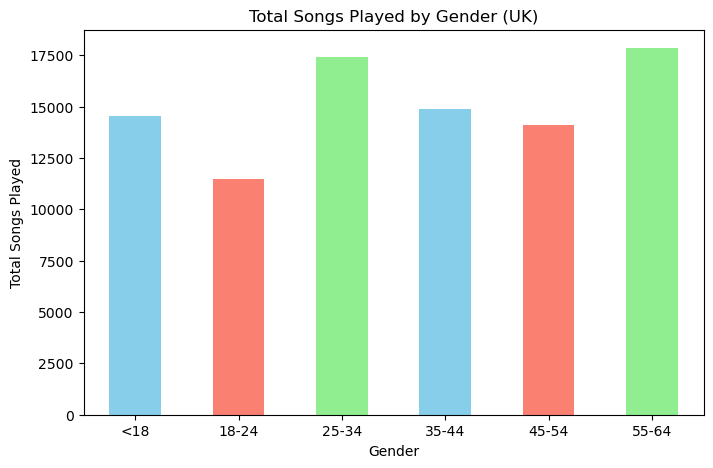

In [ ]:

plt.figure(figsize=(8,5))
total_songs_by_gender.plot(kind='bar', color=['skyblue', 'salmon', 'lightgreen'])
plt.xlabel('Age Groups')
plt.ylabel('Total Songs Played')
plt.title('Total Songs Played by Gender (UK)')
plt.xticks(rotation=0)
plt.show()

In [52]:
avg_skip = uk_data.groupby('churned')['skip_rate'].mean()
print("Average Skip Rate: Churned vs Non-churned Users (Uk)")
print(avg_skip)

Average Skip Rate: Churned vs Non-churned Users (Uk)
churned
0    0.168852
1    0.161017
Name: skip_rate, dtype: float64


In [53]:
skip_by_gender_churn = uk_data.groupby(['gender', 'churned'])['skip_rate'].mean()
print(skip_by_gender_churn)

gender  churned
Female  0          0.169767
        1          0.154762
Male    0          0.169828
        1          0.169697
Other   0          0.164286
        1          0.130000
Name: skip_rate, dtype: float64


In [54]:
skip_pivot = skip_by_gender_churn.unstack()
print(skip_pivot) 

churned         0         1
gender                     
Female   0.169767  0.154762
Male     0.169828  0.169697
Other    0.164286  0.130000


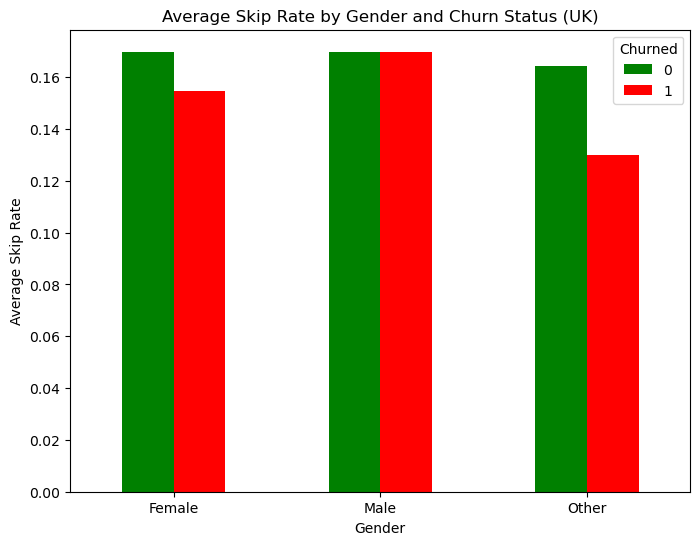

In [55]:
skip_pivot.plot(kind='bar', figsize=(8,6), color=['green','red'])
plt.ylabel('Average Skip Rate')
plt.xlabel('Gender')
plt.title('Average Skip Rate by Gender and Churn Status (UK)')
plt.xticks(rotation=0)
plt.legend(title='Churned')
plt.show()

In [56]:
uk_data.head()

,user_id,country,age,gender,subscription_type,avg_listening_hours_per_week,total_songs_played,skip_rate,satisfaction_score,churned,monthly_fee,join_date,age_groups,join_year,months_active,tenure_group
5,U1691,united kingdom,16,Female,Student,11.0,548,0.3,3.0,0,9.99,2022-04-25,<18,2022,43,41–45 Mo
7,U1490,united kingdom,57,Female,Premium,11.3,476,0.3,3.0,0,7.99,2022-12-01,55-64,2022,35,31–35 Mo
12,U1387,united kingdom,49,Female,Free,11.2,508,0.1,5.0,1,9.99,2022-02-05,45-54,2022,45,41–45 Mo
17,U1508,united kingdom,48,Female,Family,8.7,511,0.3,4.0,1,0.00,2022-09-18,45-54,2022,38,36–40 Mo
22,U1424,united kingdom,26,Female,Student,9.5,498,0.1,3.0,0,9.99,2022-10-11,25-34,2022,37,36–40 Mo


In [57]:
churned_avg_listening_hours = churned_users.groupby('gender')['avg_listening_hours_per_week'].mean()
print(churned_avg_listening_hours)

gender
Female     9.247619
Male      10.439394
Other     10.960000
Name: avg_listening_hours_per_week, dtype: float64


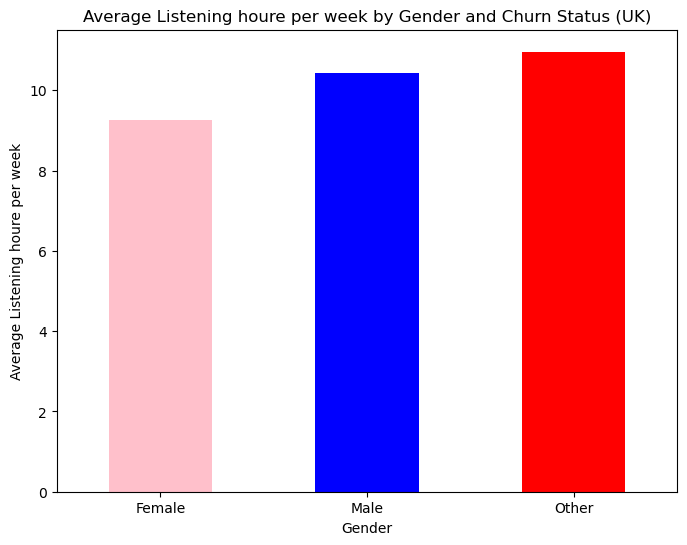

In [58]:
churned_avg_listening_hours.plot(kind='bar', figsize=(8,6), color=['pink','blue','red'])
plt.ylabel('Average Listening houre per week')
plt.xlabel('Gender')
plt.title('Average Listening houre per week by Gender and Churn Status (UK)')
plt.xticks(rotation=0)
plt.show()

In [59]:
chured_total_song = churned_users.groupby("gender")['total_songs_played'].mean()
print(chured_total_song)

gender
Female    497.523810
Male      496.393939
Other     519.600000
Name: total_songs_played, dtype: float64


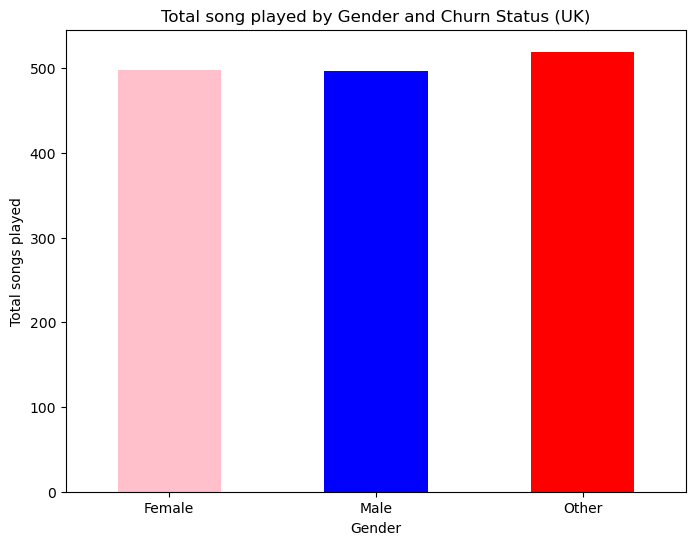

In [60]:
chured_total_song.plot(kind='bar', figsize=(8,6), color=['pink','blue','red'])
plt.ylabel('Total songs played')
plt.xlabel('Gender')
plt.title('Total song played by Gender and Churn Status (UK)')
plt.xticks(rotation=0)
plt.show()

In [61]:
avg_satisfaction = uk_data.groupby('churned')['satisfaction_score'].mean()
print("Average Satisfaction Score: Churned vs Non-Churned (UK)")
print(avg_satisfaction)


Average Satisfaction Score: Churned vs Non-Churned (UK)
churned
0    3.140893
1    3.379599
Name: satisfaction_score, dtype: float64


In [62]:
satisfaction_gender_churn = uk_data.groupby(['gender','churned'])['satisfaction_score'].mean()
print(satisfaction_gender_churn)

gender  churned
Female  0          3.314614
        1          3.482481
Male    0          3.024074
        1          3.341340
Other   0          3.107819
        1          3.200000
Name: satisfaction_score, dtype: float64


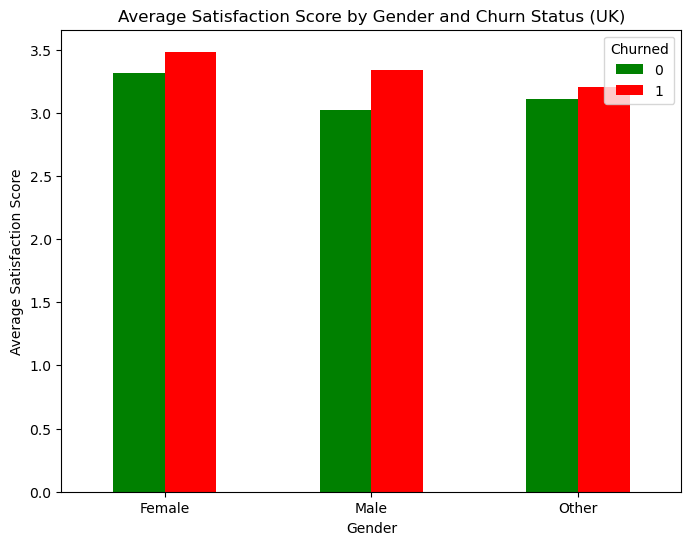

In [63]:
satisfaction_gender_churn.unstack().plot(kind='bar', figsize=(8,6), color=['green','red'])
plt.ylabel('Average Satisfaction Score')
plt.xlabel('Gender')
plt.title('Average Satisfaction Score by Gender and Churn Status (UK)')
plt.xticks(rotation=0)
plt.legend(title='Churned')
plt.show()

In [64]:
satisfaction_age_churn = uk_data.groupby(['age_groups','churned'])['satisfaction_score'].mean()
print(satisfaction_gender_churn)

gender  churned
Female  0          3.314614
        1          3.482481
Male    0          3.024074
        1          3.341340
Other   0          3.107819
        1          3.200000
Name: satisfaction_score, dtype: float64


C:\Users\Miraj Gansi\AppData\Local\Temp\ipykernel_14308\3044093829.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  satisfaction_age_churn = uk_data.groupby(['age_groups','churned'])['satisfaction_score'].mean()


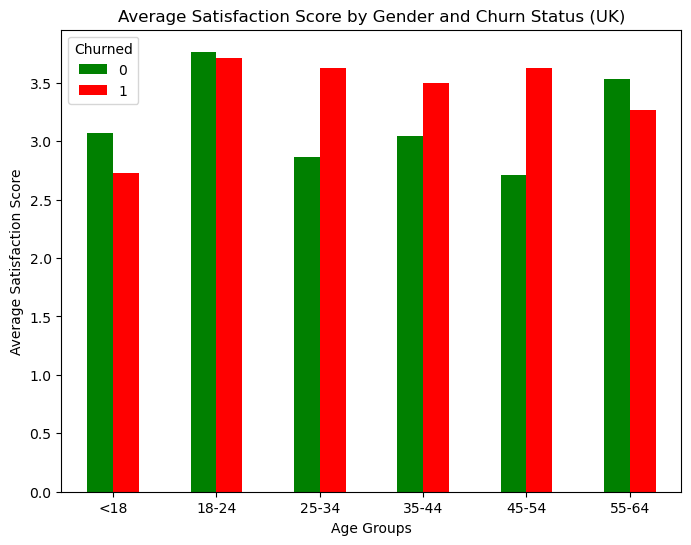

In [65]:
satisfaction_age_churn.unstack().plot(kind='bar', figsize=(8,6), color=['green','red'])
plt.ylabel('Average Satisfaction Score')
plt.xlabel('Age Groups')
plt.title('Average Satisfaction Score by Gender and Churn Status (UK)')
plt.xticks(rotation=0)
plt.legend(title='Churned')
plt.show()

In [66]:
# Numeric columns to analyze
metrics = ['avg_listening_hours_per_week', 'skip_rate', 'satisfaction_score']

# Group by churned and calculate mean
summary_table_churened = churned_users.groupby('age_groups')[metrics].mean()
summary_table_churened


C:\Users\Miraj Gansi\AppData\Local\Temp\ipykernel_14308\2168677492.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_table_churened = churned_users.groupby('age_groups')[metrics].mean()


,avg_listening_hours_per_week,skip_rate,satisfaction_score
age_groups,,,
<18,10.290000,0.180000,2.726421
18-24,9.400000,0.142857,3.714286
25-34,9.861538,0.142308,3.625546
35-44,13.116667,0.175000,3.500000
45-54,9.162500,0.168750,3.625000
55-64,9.640000,0.163333,3.266667


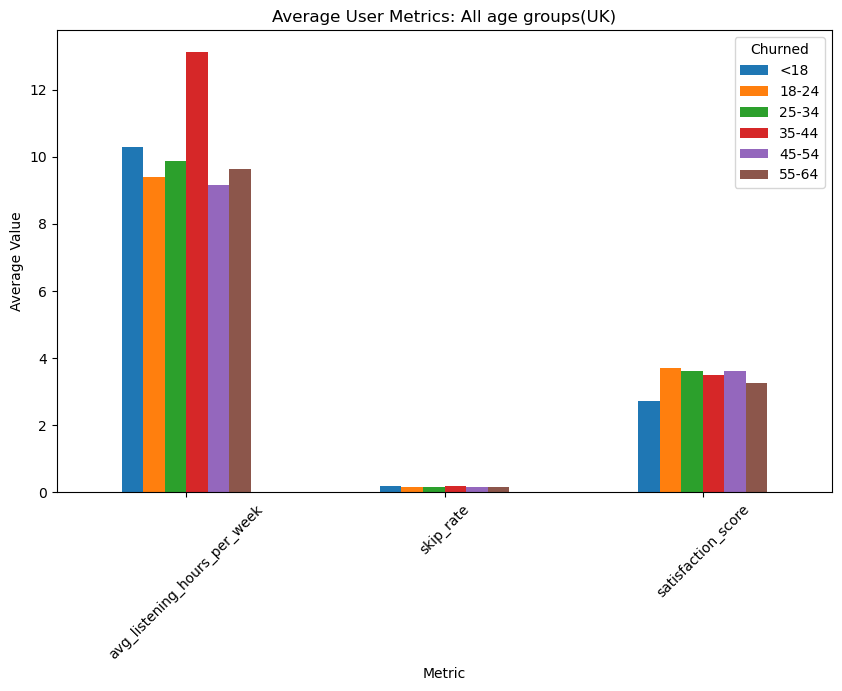

In [67]:
summary_table_churened.T.plot(kind='bar', figsize=(10,6), )
plt.ylabel('Average Value')
plt.xlabel('Metric')
plt.title('Average User Metrics: All age groups(UK)')
plt.xticks(rotation=45)
plt.legend(title='Churned')
plt.show()

In [68]:
metrics = ['avg_listening_hours_per_week', 'skip_rate', 'satisfaction_score']

# Group by age group and churned status
summary_table = uk_data.groupby(['age_groups','churned'])[metrics].mean()
summary_table


C:\Users\Miraj Gansi\AppData\Local\Temp\ipykernel_14308\890615313.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary_table = uk_data.groupby(['age_groups','churned'])[metrics].mean()


avg_listening_hours_per_week  skip_rate  \
age_groups churned                                            
<18        0                           10.594737   0.184211   
           1                           10.290000   0.180000   
18-24      0                            9.993750   0.187500   
           1                            9.400000   0.142857   
25-34      0                           10.790909   0.163636   
           1                            9.861538   0.142308   
35-44      0                           11.029167   0.166667   
           1                           13.116667   0.175000   
45-54      0                           10.075000   0.157500   
           1                            9.162500   0.168750   
55-64      0                           10.657143   0.159524   
           1                            9.640000   0.163333   

                    satisfaction_score  
age_groups churned                      
<18        0                  3.066537  
           1                  2.726421  
18-24      0                  3.766513  
           1                  3.714286  
25-34      0                  2.863636  
           1                  3.625546  
35-44      0                  3.047171  
           1                  3.500000  
45-54      0                  2.713210  
           1                  3.625000  
55-64      0                  3.536391  
           1                  3.266667

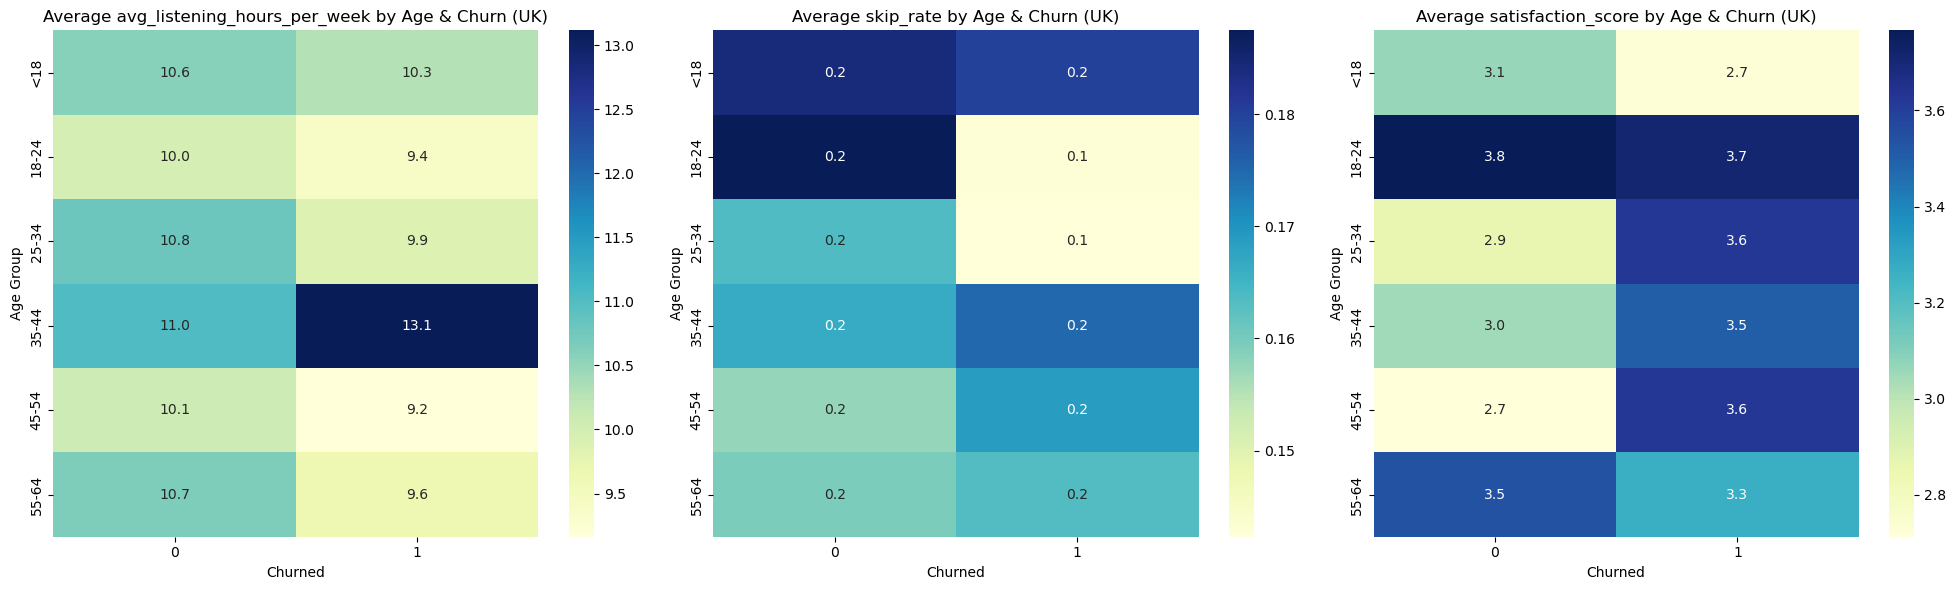

In [69]:
fig, axes = plt.subplots(1, 3, figsize=(20,6))

for i, metric in enumerate(metrics):
    # Pivot for heatmap
    heatmap_data_pivot = summary_table[metric].unstack()  # churned as columns
    sns.heatmap(heatmap_data_pivot, annot=True, fmt=".1f", cmap="YlGnBu", ax=axes[i])
    axes[i].set_title(f'Average {metric} by Age & Churn (UK)')
    axes[i].set_xlabel('Churned')
    axes[i].set_ylabel('Age Group')

plt.tight_layout()
plt.show()

In [70]:
scaler = MinMaxScaler()

uk_data[['listening_norm', 'skip_norm', 'satisfaction_norm']] = scaler.fit_transform(
    uk_data[['avg_listening_hours_per_week', 'skip_rate', 'satisfaction_score']]
)

C:\Users\Miraj Gansi\AppData\Local\Temp\ipykernel_14308\2145399818.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  uk_data[['listening_norm', 'skip_norm', 'satisfaction_norm']] = scaler.fit_transform(
C:\Users\Miraj Gansi\AppData\Local\Temp\ipykernel_14308\2145399818.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  uk_data[['listening_norm', 'skip_norm', 'satisfaction_norm']] = scaler.fit_transform(
C:\Users\Miraj Gansi\AppData\Local\Temp\ipykernel_14308\2145399818.py:3: SettingWithCopyWarning: 
A va

In [71]:
uk_data['listening_norm'] = (uk_data['avg_listening_hours_per_week'] - uk_data['avg_listening_hours_per_week'].min()) / \
                        (uk_data['avg_listening_hours_per_week'].max() - uk_data['avg_listening_hours_per_week'].min())

uk_data['skip_norm'] = (uk_data['skip_rate'] - uk_data['skip_rate'].min()) / \
                  (uk_data['skip_rate'].max() - uk_data['skip_rate'].min())

uk_data['satisfaction_norm'] = (uk_data['satisfaction_score'] - uk_data['satisfaction_score'].min()) / \
                          (uk_data['satisfaction_score'].max() - uk_data['satisfaction_score'].min())


C:\Users\Miraj Gansi\AppData\Local\Temp\ipykernel_14308\2796230277.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  uk_data['listening_norm'] = (uk_data['avg_listening_hours_per_week'] - uk_data['avg_listening_hours_per_week'].min()) / \
C:\Users\Miraj Gansi\AppData\Local\Temp\ipykernel_14308\2796230277.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  uk_data['skip_norm'] = (uk_data['skip_rate'] - uk_data['skip_rate'].min()) / \
C:\Users\Miraj Gansi\AppData\Local\Temp\ipykernel_14308\2796230277.py:7: 

In [72]:
uk_data['composite_score'] = (
    uk_data['listening_norm']
    + (1 - uk_data['skip_norm'])
    + uk_data['satisfaction_norm']
)

C:\Users\Miraj Gansi\AppData\Local\Temp\ipykernel_14308\1794895081.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  uk_data['composite_score'] = (


In [73]:
avg_composite_by_churn = uk_data.groupby(['age_groups','churned'])['composite_score'].mean()
print(avg_composite_by_churn)

age_groups  churned
<18         0          1.427841
            1          1.346519
18-24       0          1.563773
            1          1.703695
25-34       0          1.467868
            1          1.703601
35-44       0          1.511901
            1          1.681753
45-54       0          1.423949
            1          1.567565
55-64       0          1.646741
            1          1.520230
Name: composite_score, dtype: float64


C:\Users\Miraj Gansi\AppData\Local\Temp\ipykernel_14308\1827707911.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_composite_by_churn = uk_data.groupby(['age_groups','churned'])['composite_score'].mean()


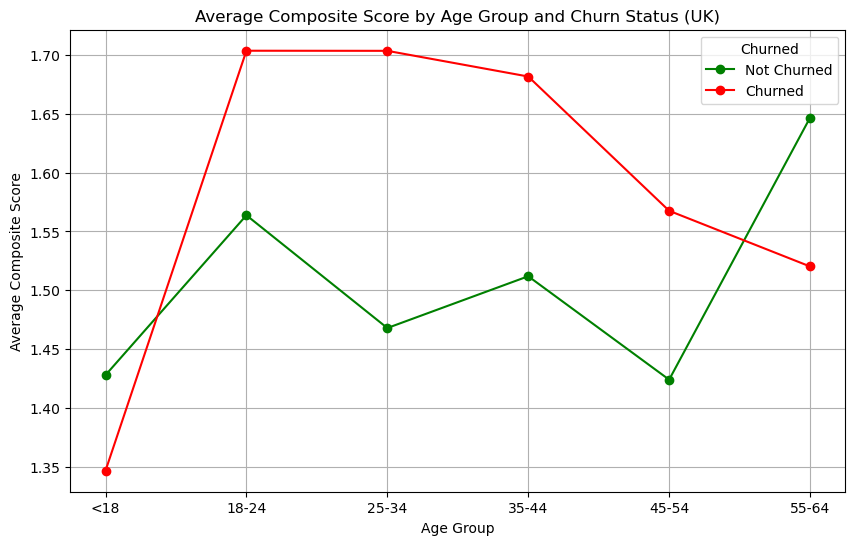

In [74]:

composite_pivot = avg_composite_by_churn.unstack()  
plt.figure(figsize=(10,6))
plt.plot(composite_pivot.index, composite_pivot[0], marker='o', label='Not Churned', color='green')
plt.plot(composite_pivot.index, composite_pivot[1], marker='o', label='Churned', color='red')

plt.title('Average Composite Score by Age Group and Churn Status (UK)')
plt.xlabel('Age Group')
plt.ylabel('Average Composite Score')
plt.legend(title='Churned')
plt.xticks(rotation=0)
plt.grid(True)
plt.show()

In [75]:
composite_by_tenure = uk_data.groupby(['tenure_group','churned'])['composite_score'].mean().unstack()
print(composite_by_tenure)

churned              0         1
tenure_group                    
11–15 Mo      1.477874  1.476239
16–20 Mo      1.636605  1.832866
21–25 Mo      1.287853  1.779667
26–30 Mo      1.458530  1.698689
31–35 Mo      1.472633  1.606705
36–40 Mo      1.561978  1.370925
41–45 Mo      1.513351  1.346724


C:\Users\Miraj Gansi\AppData\Local\Temp\ipykernel_14308\1663673839.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  composite_by_tenure = uk_data.groupby(['tenure_group','churned'])['composite_score'].mean().unstack()


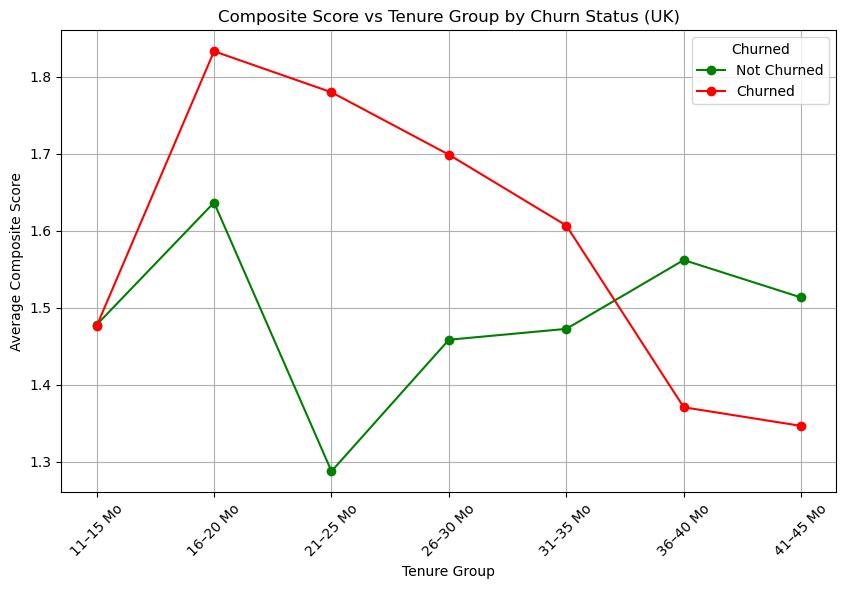

In [76]:
plt.figure(figsize=(10,6))
plt.plot(composite_by_tenure.index, composite_by_tenure[0], marker='o', label='Not Churned', color='green')
plt.plot(composite_by_tenure.index, composite_by_tenure[1], marker='o', label='Churned', color='red')

plt.title('Composite Score vs Tenure Group by Churn Status (UK)')
plt.xlabel('Tenure Group')
plt.ylabel('Average Composite Score')
plt.xticks(rotation=45)
plt.legend(title='Churned')
plt.grid(True)
plt.show()


In [77]:
tenure_filtered = uk_data[(uk_data['churned'] == 1) & (uk_data['tenure_group'].isin(['16–20 Mo', '21–25 Mo']))]

In [78]:
fee_by_churn = tenure_filtered.groupby(['tenure_group', 'churned'])['monthly_fee'].mean().unstack()
print(fee_by_churn)

churned            1
tenure_group        
11–15 Mo         NaN
16–20 Mo      7.9925
21–25 Mo      9.9900
26–30 Mo         NaN
31–35 Mo         NaN
36–40 Mo         NaN
41–45 Mo         NaN


C:\Users\Miraj Gansi\AppData\Local\Temp\ipykernel_14308\2245426328.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fee_by_churn = tenure_filtered.groupby(['tenure_group', 'churned'])['monthly_fee'].mean().unstack()


In [79]:
summary = tenure_filtered.groupby('age_groups').agg(
    avg_monthly_fee=('monthly_fee', 'mean'),
    avg_composite_score=('composite_score', 'mean')
).reset_index()
summary

C:\Users\Miraj Gansi\AppData\Local\Temp\ipykernel_14308\108281391.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  summary = tenure_filtered.groupby('age_groups').agg(


,age_groups,avg_monthly_fee,avg_composite_score
0,<18,11.490,1.082030
1,18-24,7.990,1.821552
2,25-34,5.245,2.008405
3,35-44,9.990,1.885345
4,45-54,11.490,1.626724
5,55-64,9.740,1.992888


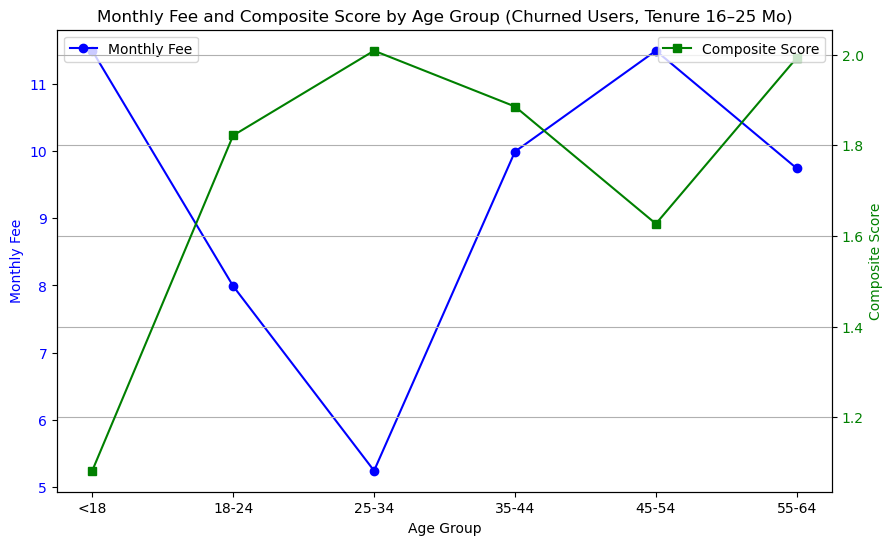

In [80]:

fig, ax1 = plt.subplots(figsize=(10,6))

ax1.plot(summary['age_groups'], summary['avg_monthly_fee'], color='blue', marker='o', label='Monthly Fee')
ax1.set_xlabel('Age Group')
ax1.set_ylabel('Monthly Fee', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.plot(summary['age_groups'], summary['avg_composite_score'], color='green', marker='s', label='Composite Score')
ax2.set_ylabel('Composite Score', color='green')
ax2.tick_params(axis='y', labelcolor='green')

plt.title('Monthly Fee and Composite Score by Age Group (Churned Users, Tenure 16–25 Mo)')
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.grid(True)
plt.show()

In [81]:
uk_data['skip_rate'].unique 

<bound method Series.unique of 5      0.30
7      0.30
12     0.10
17     0.30
22     0.10
       ... 
672    0.25
676    0.25
678    0.25
687    0.25
690    0.30
Name: skip_rate, Length: 181, dtype: float64>

In [82]:
uk_data

,user_id,country,age,gender,subscription_type,avg_listening_hours_per_week,total_songs_played,skip_rate,satisfaction_score,churned,monthly_fee,join_date,age_groups,join_year,months_active,tenure_group,listening_norm,skip_norm,satisfaction_norm,composite_score
5,U1691,united kingdom,16,Female,Student,11.0,548,0.30,3.0,0,9.99,2022-04-25,<18,2022,43,41–45 Mo,0.465517,1.0,0.50,0.965517
7,U1490,united kingdom,57,Female,Premium,11.3,476,0.30,3.0,0,7.99,2022-12-01,55-64,2022,35,31–35 Mo,0.478448,1.0,0.50,0.978448
12,U1387,united kingdom,49,Female,Free,11.2,508,0.10,5.0,1,9.99,2022-02-05,45-54,2022,45,41–45 Mo,0.474138,0.2,1.00,2.274138
17,U1508,united kingdom,48,Female,Family,8.7,511,0.30,4.0,1,0.00,2022-09-18,45-54,2022,38,36–40 Mo,0.366379,1.0,0.75,1.116379
22,U1424,united kingdom,26,Female,Student,9.5,498,0.10,3.0,0,9.99,2022-10-11,25-34,2022,37,36–40 Mo,0.400862,0.2,0.50,1.700862
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
672,U1104,united kingdom,22,Female,Premium,2.0,497,0.25,5.0,0,9.99,2023-07-12,18-24,2023,28,26–30 Mo,0.077586,0.8,1.00,1.277586
676,U1679,united kingdom,40,Other,Free,2.1,462,0.25,1.0,0,9.99,2022-06-06,35-44,2022,41,41–45 Mo,0.081897,0.8,0.00,0.281897
678,U1229,united kingdom,34,Male,Free,19.4,508,0.25,1.0,0,7.99,2022-08-04,25-34,2022,39,36–40 Mo,0.827586,0.8,0.00,1.027586
687,U1418,united kingdom,42,Male,Family,6.7,507,0.25,5.0,0,0.00,2024-07-02,35-44,2024,16,16–20 Mo,0.280172,0.8,1.00,1.480172
